<a href="https://colab.research.google.com/github/joysujeeth1761/Adversarial_ML/blob/main/BOUNDARY_BASED_ATTACKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**deep fool and Brendel & Bethge**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
# MNIST TRANSFORM

transform = transforms.ToTensor()

# TRAIN DATASET

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# TEST DATASET

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# DATALOADERS

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

print("MNIST Dataset Loaded")

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

MNIST Dataset Loaded


In [4]:
#build CNN model
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 5 * 5)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model Initialized")

Model Initialized


In [6]:
#training CNN model
epochs = 3

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

print("Training Completed")

Epoch 1, Loss: 171.7938
Epoch 2, Loss: 49.3515
Epoch 3, Loss: 35.0940
Training Completed


In [7]:
def test_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Normal Accuracy: {accuracy:.2f}%")

In [8]:
test_accuracy(model, test_loader)

Normal Accuracy: 98.67%


In [9]:
def show_image(img, title):

    img = img.squeeze().cpu().detach().numpy()

    plt.imshow(img, cmap='gray')

    plt.title(title)

    plt.axis('off')

    plt.show()

In [10]:
#Deep fool attack function
def deepfool_attack(model,
                    image,
                    num_classes=10,
                    overshoot=0.02,
                    max_iter=50):

    model.eval()

    image = image.clone().detach().to(device)

    perturbed_image = image.clone().detach()

    perturbed_image.requires_grad = True

    output = model(perturbed_image)

    _, label = torch.max(output.data, 1)

    original_label = label.item()

    iteration = 0

    while iteration < max_iter:

        output = model(perturbed_image)

        current_label = output.argmax(dim=1).item()

        # Stop if prediction changes
        if current_label != original_label:
            break

        model.zero_grad()

        output[0, original_label].backward(
            retain_graph=True
        )

        grad_orig = perturbed_image.grad.data.clone()

        min_distance = float('inf')

        perturbation = None

        # Compare with all classes
        for k in range(num_classes):

            if k == original_label:
                continue

            perturbed_image.grad.zero_()

            model.zero_grad()

            output[0, k].backward(
                retain_graph=True
            )

            grad_k = perturbed_image.grad.data.clone()

            # Gradient difference
            w_k = grad_k - grad_orig

            # Logit difference
            f_k = (
                output[0, k]
                - output[0, original_label]
            ).data

            # Distance to decision boundary
            distance = abs(f_k) / torch.norm(
                w_k.view(-1),
                p=2
            )

            # Find nearest boundary
            if distance < min_distance:

                min_distance = distance

                perturbation = (
                    distance * w_k
                    / torch.norm(
                        w_k.view(-1),
                        p=2
                    )
                )

        # Apply perturbation
        perturbed_image = (
            perturbed_image
            + (1 + overshoot) * perturbation
        ).detach()

        perturbed_image.requires_grad = True

        iteration += 1

    return perturbed_image.detach()

In [11]:
# generate adversial example
# GET TEST IMAGE

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

# GENERATE ADVERSARIAL IMAGE

adv_image = deepfool_attack(
    model,
    images
)

print("DeepFool Attack Completed")

DeepFool Attack Completed


In [12]:
# ORIGINAL PREDICTION

output1 = model(images)
pred1 = output1.argmax(dim=1)

# ADVERSARIAL PREDICTION

output2 = model(adv_image)
pred2 = output2.argmax(dim=1)

print("Original Prediction:", pred1.item())

print("Adversarial Prediction:", pred2.item())

Original Prediction: 3
Adversarial Prediction: 5


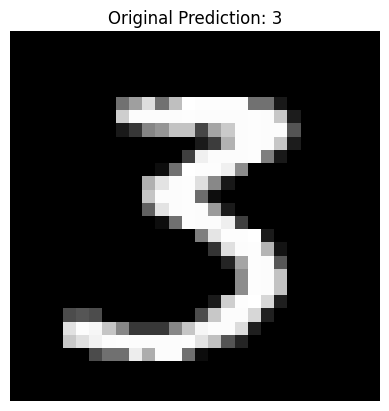

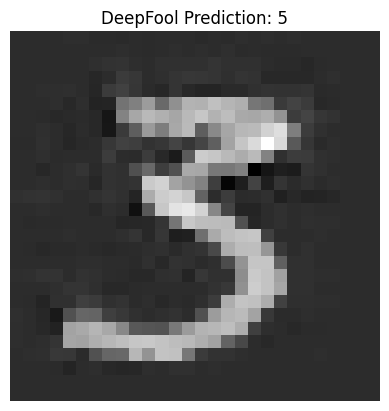

In [13]:
show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"DeepFool Prediction: {pred2.item()}"
)

**Brendel & Bethgen attack**

In [14]:
#Brendel & Bethge needs an initial adversarial example,
#so build FGSM attack
def fgsm_attack(model,
                image,
                label,
                epsilon=0.3):

    image.requires_grad = True

    output = model(image)

    loss = loss_fn(output, label)

    model.zero_grad()

    loss.backward()

    gradient = image.grad.data

    perturbed_image = (
        image
        + epsilon * gradient.sign()
    )

    perturbed_image = torch.clamp(
        perturbed_image,
        0,
        1
    )

    return perturbed_image.detach()



In [15]:
#Brendel & Bethge Attack
def brendel_bethge_attack(model,
                          image,
                          label,
                          steps=50,
                          alpha=0.01):

    model.eval()

    # Initial adversarial example
    adv_image = fgsm_attack(
        model,
        image,
        label,
        epsilon=0.3
    )

    original_image = image.clone().detach()

    for step in range(steps):

        adv_image.requires_grad = True

        output = model(adv_image)

        current_label = output.argmax(dim=1)

        # Stop if attack fails
        if current_label.item() == label.item():
            break

        # Compute gradient
        loss = loss_fn(output, label)

        model.zero_grad()

        loss.backward()

        gradient = adv_image.grad.data

        # Normalize gradient
        gradient = (
            gradient
            / torch.norm(
                gradient.view(-1),
                p=2
            )
        )

        # Move toward original image
        direction = original_image - adv_image

        direction = (
            direction
            / torch.norm(
                direction.view(-1),
                p=2
            )
        )

        # Boundary-following update
        adv_image = (
            adv_image
            + alpha * direction
            - alpha * gradient
        ).detach()

        adv_image = torch.clamp(
            adv_image,
            0,
            1
        )

    return adv_image.detach()

In [24]:
# generate adversial example
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = brendel_bethge_attack(
    model,
    images,
    labels
)

print("Brendel & Bethge Attack Completed")

Brendel & Bethge Attack Completed


In [29]:
# accuracy test for B&B
# ==========================================
# TEST BRENDEL & BETHGE ACCURACY
# ==========================================

def test_brendel_bethge(model,
                         loader,
                         steps=50,
                         alpha=0.01):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial images
        adv_images = brendel_bethge_attack(
            model,
            images,
            labels,
            steps=steps,
            alpha=alpha
        )

        # Predict adversarial images
        outputs = model(adv_images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Brendel & Bethge Accuracy: {accuracy:.2f}%"
    )

In [30]:
test_brendel_bethge(
    model,
    test_loader
)

Brendel & Bethge Accuracy: 50.15%


In [27]:
# comparision of predictions
output1 = model(images)
pred1 = output1.argmax(dim=1)

output2 = model(adv_image)
pred2 = output2.argmax(dim=1)

print("Original Prediction:", pred1.item())

print("Adversarial Prediction:", pred2.item())

Original Prediction: 7
Adversarial Prediction: 3


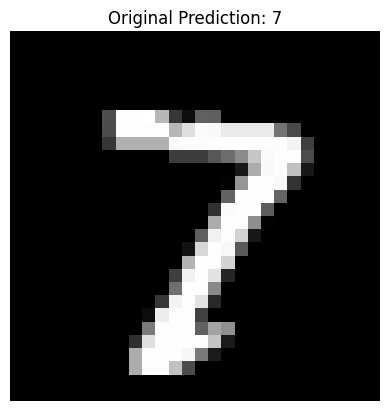

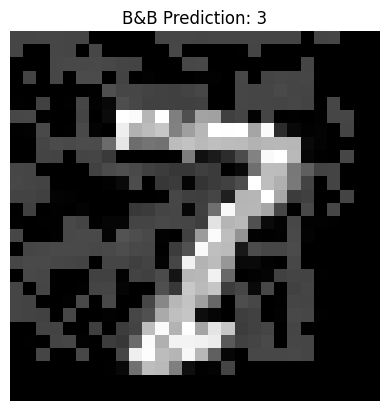

In [28]:
# visualize images
show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"B&B Prediction: {pred2.item()}"
)